### Steps followed:
1. Load clean datasets and confirm baseline
2. Post-cleaning feature distributions — confirm imputations worked
3. Reject inference analysis
   - Load rejected loans dataset
   - Compare accepted vs rejected borrower profiles
   - Document selection bias implications
4. Summary — key findings and implications for modelling

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)

print(f"pandas:  {pd.__version__}")
print(f"numpy:   {np.__version__}")

pandas:  3.0.1
numpy:   2.4.3


In [28]:
# Load Clean Datasets and Confirm Baseline

df_train = pd.read_pickle("../data/processed/df_train.pkl")
df_test  = pd.read_pickle("../data/processed/df_test.pkl")
df_clean = pd.read_pickle("../data/processed/df_clean.pkl")

print("Datasets loaded successfully")
print()
print(f"{'Dataset':<12} {'Rows':>10} {'Columns':>10} {'Default Rate':>14} {'Missing':>10}")
print("─" * 60)
for name, d in [("df_clean", df_clean), ("df_train", df_train), ("df_test", df_test)]:
    print(f"{name:<12} {len(d):>10,} {d.shape[1]:>10} "
          f"{d['default_flag'].mean()*100:>13.2f}% "
          f"{d.isnull().sum().sum():>10,}")

print()
print(f"Train years: {df_train['issue_year'].min()}–{df_train['issue_year'].max()}")
print(f"Test years:  {df_test['issue_year'].min()}–{df_test['issue_year'].max()}")

Datasets loaded successfully

Dataset            Rows    Columns   Default Rate    Missing
────────────────────────────────────────────────────────────
df_clean      1,348,099         68         19.98%          0
df_train        829,355         68         18.46%          0
df_test         518,744         68         22.42%          0

Train years: 2007–2015
Test years:  2016–2018


### Objective

1. Validate the cleaned dataset — confirm imputations worked correctly
   and distributions are sensible post-cleaning
2. Analyse rejected loan applications to understand selection bias —
   Lending Club only accepted a subset of applicants, meaning the
   population we model on is not representative of all credit seekers

## Section 1 — post-cleaning feature distributions

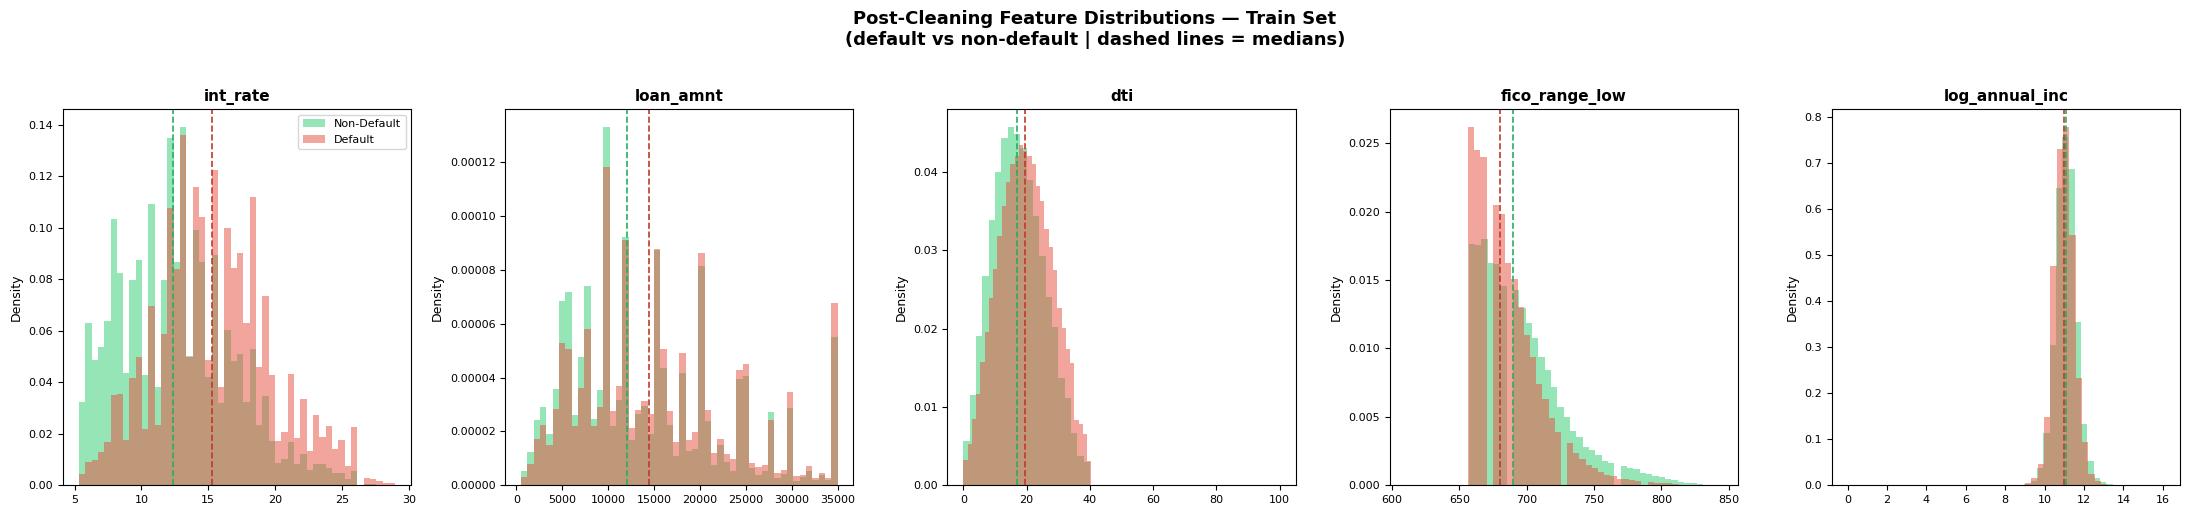

Saved: outputs/post_cleaning_distributions.png


In [29]:
# Post-cleaning distribution check — key features

key_features = ["int_rate", "loan_amnt", "dti", "fico_range_low", "log_annual_inc"]

fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for i, col in enumerate(key_features):
    d0 = df_train[df_train["default_flag"] == 0][col]
    d1 = df_train[df_train["default_flag"] == 1][col]

    axes[i].hist(d0, bins=50, alpha=0.5, color="#2ecc71",
                 density=True, label="Non-Default")
    axes[i].hist(d1, bins=50, alpha=0.5, color="#e74c3c",
                 density=True, label="Default")
    axes[i].axvline(d0.median(), color="#27ae60", linestyle="--", linewidth=1.2)
    axes[i].axvline(d1.median(), color="#c0392b", linestyle="--", linewidth=1.2)
    axes[i].set_title(col, fontsize=11, fontweight="bold")
    axes[i].set_ylabel("Density", fontsize=9)
    axes[i].tick_params(labelsize=8)

axes[0].legend(fontsize=8)

plt.suptitle(
    "Post-Cleaning Feature Distributions — Train Set\n"
    "(default vs non-default | dashed lines = medians)",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("../outputs/post_cleaning_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/post_cleaning_distributions.png")

The dti plot has a problem — the x-axis runs to 1000, which means there are extreme outliers compressing the entire distribution to the left. Everything appears near zero because a handful of loans have impossible DTI values.

In [30]:
print(f"dti max in df_train: {df_train['dti'].max():.2f}")
print(f"dti max in df_test:  {df_test['dti'].max():.2f}")
print(f"dti extreme (>100) in df_train: {(df_train['dti'] > 100).sum()}")

dti max in df_train: 100.00
dti max in df_test:  100.00
dti extreme (>100) in df_train: 0


## Section 2 : Reject Inference Analysis 

In [31]:
# Load rejected loans dataset
df_rejected = pd.read_csv(
    "../data/raw/rejected_2007_to_2018Q4.csv",
    low_memory=False
)

print(f"Rejected loans shape: {df_rejected.shape}")
print()
print("Columns:")
print(df_rejected.columns.tolist())

Rejected loans shape: (27648741, 9)

Columns:
['Amount Requested', 'Application Date', 'Loan Title', 'Risk_Score', 'Debt-To-Income Ratio', 'Zip Code', 'State', 'Employment Length', 'Policy Code']


In [32]:
# Clean and align rejected loans for comparison

df_rej = df_rejected.copy()

# Rename to match accepted loan column names
df_rej = df_rej.rename(columns={
    "Amount Requested"    : "loan_amnt",
    "Risk_Score"          : "fico_range_low",
    "Debt-To-Income Ratio": "dti",
    "Employment Length"   : "emp_length",
    "Application Date"    : "app_date"
})

# Clean dti — stored as string with % sign in rejected file
df_rej["dti"] = (
    df_rej["dti"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .str.strip()
)
df_rej["dti"] = pd.to_numeric(df_rej["dti"], errors="coerce")

# Clean loan_amnt and fico_range_low
df_rej["loan_amnt"]     = pd.to_numeric(df_rej["loan_amnt"], errors="coerce")
df_rej["fico_range_low"] = pd.to_numeric(df_rej["fico_range_low"], errors="coerce")

# Extract year from application date
df_rej["issue_year"] = pd.to_datetime(
    df_rej["app_date"], errors="coerce"
).dt.year

# Drop rows with missing key fields
df_rej_clean = df_rej[["loan_amnt", "fico_range_low", "dti",
                         "emp_length", "issue_year"]].dropna(
    subset=["loan_amnt", "fico_range_low", "dti"]
)

print(f"Rejected loans after cleaning: {len(df_rej_clean):,}")
print()
print("Summary stats — rejected loans:")
print(df_rej_clean[["loan_amnt", "fico_range_low", "dti"]].describe().round(2))

Rejected loans after cleaning: 9,151,111

Summary stats — rejected loans:
         loan_amnt  fico_range_low           dti
count 9151111.0000    9151111.0000  9151111.0000
mean    12627.4800        628.1700      168.7800
std     10890.3000         89.9400    17621.0900
min         0.0000          0.0000       -1.0000
25%      4000.0000        591.0000        8.9700
50%     10000.0000        637.0000       20.4200
75%     20000.0000        675.0000       36.0400
max   1400000.0000        990.0000 50000031.4900


In [33]:
# Cap extreme values in rejected loans before comparison

# dti — cap at 100 (same as accepted loans)
df_rej_clean = df_rej_clean.copy()
df_rej_clean["dti"] = df_rej_clean["dti"].clip(lower=0, upper=100)

# loan_amnt — cap at 99th percentile
loan_amnt_cap = df_rej_clean["loan_amnt"].quantile(0.99)
df_rej_clean["loan_amnt"] = df_rej_clean["loan_amnt"].clip(upper=loan_amnt_cap)

# fico_range_low — valid FICO range is 300–850
df_rej_clean = df_rej_clean[
    (df_rej_clean["fico_range_low"] >= 300) &
    (df_rej_clean["fico_range_low"] <= 850)
]

print(f"Rejected loans after capping: {len(df_rej_clean):,}")
print()
print("Summary stats after capping:")
print(df_rej_clean[["loan_amnt", "fico_range_low", "dti"]].describe().round(2))

Rejected loans after capping: 9,035,356

Summary stats after capping:
         loan_amnt  fico_range_low          dti
count 9035356.0000    9035356.0000 9035356.0000
mean    12649.4500        633.3800      26.6500
std     10838.8500         64.4900      24.3800
min         0.0000        300.0000       0.0000
25%      4000.0000        593.0000       9.3200
50%     10000.0000        637.0000      20.6400
75%     20000.0000        675.0000      36.2000
max     40000.0000        850.0000     100.0000


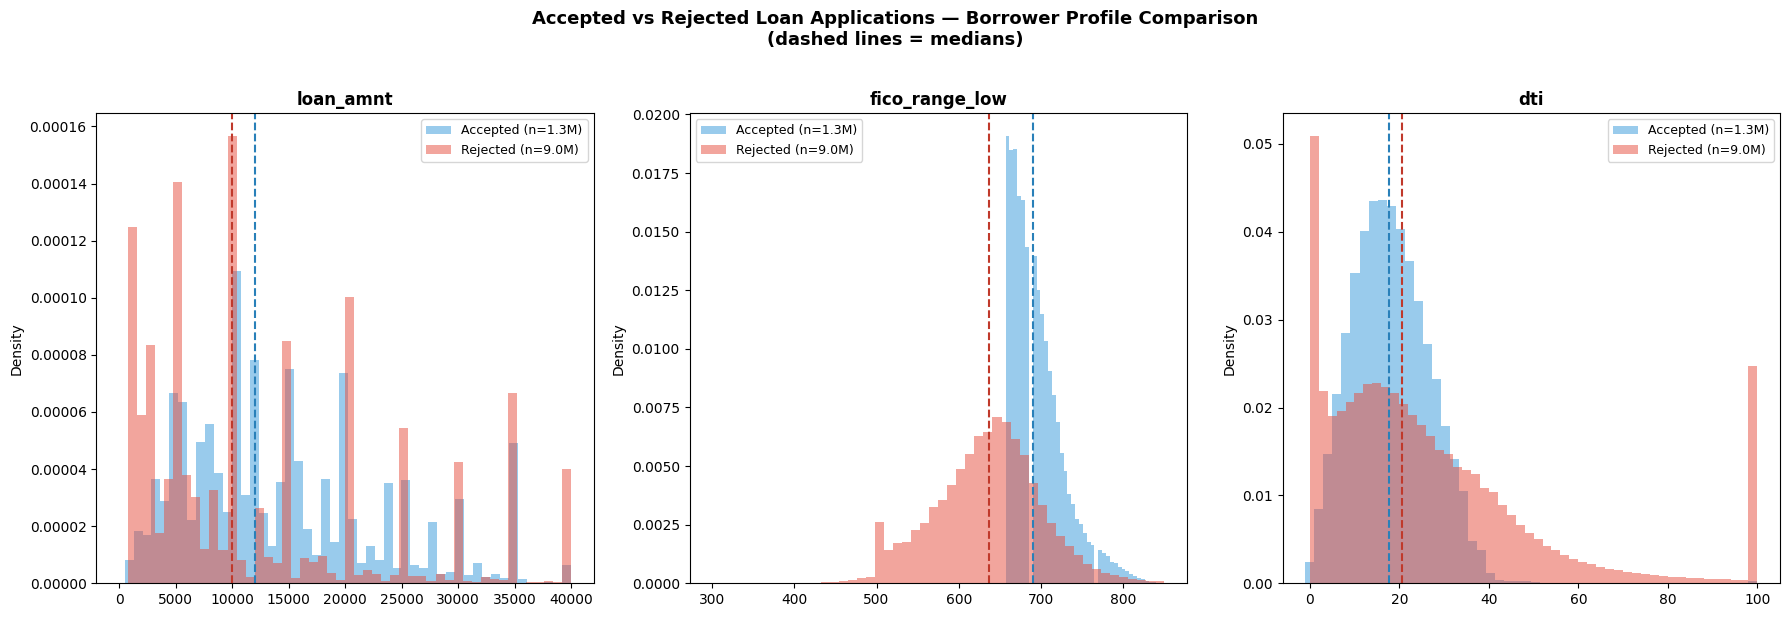

Saved: outputs/reject_inference_comparison.png

Feature                 Accepted Median    Rejected Median   Difference
────────────────────────────────────────────────────────────────────────
loan_amnt                      12000.00           10000.00      2000.00
fico_range_low                   690.00             637.00        53.00
dti                               17.61              20.64        -3.03


In [34]:
# Accepted vs rejected borrower profile comparison

# Accepted loans — use df_clean for full population
df_acc = df_clean[["loan_amnt", "fico_range_low", "dti"]].copy()

compare_features = ["loan_amnt", "fico_range_low", "dti"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, col in enumerate(compare_features):
    acc = df_acc[col].dropna()
    rej = df_rej_clean[col].dropna()

    # Cap accepted loan_amnt at same cap for fair comparison
    if col == "loan_amnt":
        acc = acc.clip(upper=40000)

    axes[i].hist(acc, bins=50, alpha=0.5, color="#3498db",
                 density=True, label=f"Accepted (n={len(acc)/1e6:.1f}M)")
    axes[i].hist(rej, bins=50, alpha=0.5, color="#e74c3c",
                 density=True, label=f"Rejected (n={len(rej)/1e6:.1f}M)")

    axes[i].axvline(acc.median(), color="#2980b9",
                    linestyle="--", linewidth=1.5)
    axes[i].axvline(rej.median(), color="#c0392b",
                    linestyle="--", linewidth=1.5)

    axes[i].set_title(col, fontsize=12, fontweight="bold")
    axes[i].set_ylabel("Density", fontsize=10)
    axes[i].legend(fontsize=9)

plt.suptitle(
    "Accepted vs Rejected Loan Applications — Borrower Profile Comparison\n"
    "(dashed lines = medians)",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("../outputs/reject_inference_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/reject_inference_comparison.png")

# Print median comparison table
print()
print(f"{'Feature':<20} {'Accepted Median':>18} {'Rejected Median':>18} {'Difference':>12}")
print("─" * 72)
for col in compare_features:
    acc_med = df_acc[col].median()
    rej_med = df_rej_clean[col].median()
    diff    = acc_med - rej_med
    print(f"{col:<20} {acc_med:>18.2f} {rej_med:>18.2f} {diff:>12.2f}")

**Summary/Key findings:**

| Feature | Accepted Median | Rejected Median | Difference |
|---------|----------------|-----------------|------------|
| loan_amnt | $12,000 | $10,000 | +$2,000 |
| fico_range_low | 690 | 637 | +53 points |
| dti | 17.61% | 20.64% | −3.03pp |

**FICO score** shows the starkest separation. Accepted borrowers have a median
FICO of 690 versus 637 for rejected applicants — a 53-point gap. The
distribution chart confirms that rejected applicants are spread across a much
wider FICO range (300–850), while accepted applicants are concentrated above
650. Lending Club's credit filter is primarily a FICO floor.

**DTI** — rejected applicants carry higher debt burdens (20.6% vs 17.6%).
The rejected distribution has a heavier right tail, indicating a meaningful
segment of high-DTI applicants being screened out.

**Loan amount** — rejected applicants requested slightly less on average
($10K vs $12K). This is counterintuitive but explainable — lower-income,
lower-FICO borrowers tend to request smaller amounts, and these are the
applicants being rejected on creditworthiness grounds.

The model is trained exclusively on accepted loans. This means it learns
default behaviour only from borrowers who passed Lending Club's credit screen.
The true default rate among all credit seekers (accepted + rejected) would be
substantially higher than the 19.98% observed in our dataset.

This means:
- The model will underestimate default risk when applied to populations
  with lower FICO scores than the accepted loan population
- Features like FICO and DTI are compressed in range — the model never sees
  FICO scores below ~600 or extreme DTI values in its training data
- This is a fundamental limitation of any model built on accepted-only data
  and should be disclosed explicitly when presenting results